In [24]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [25]:
# Step 1: Read image
image = cv2.imread("coin.jpg")

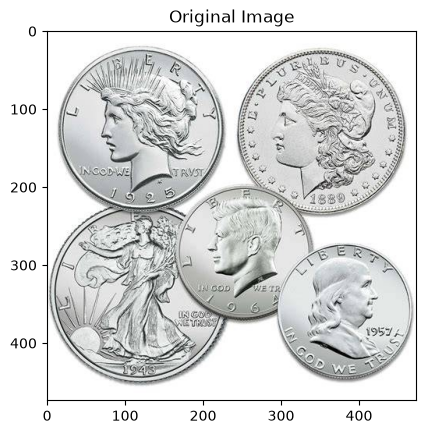

In [26]:
# Display original image
imageCopy = image.copy()
plt.imshow(image[:, :, ::-1])
plt.title("Original Image")
plt.show()


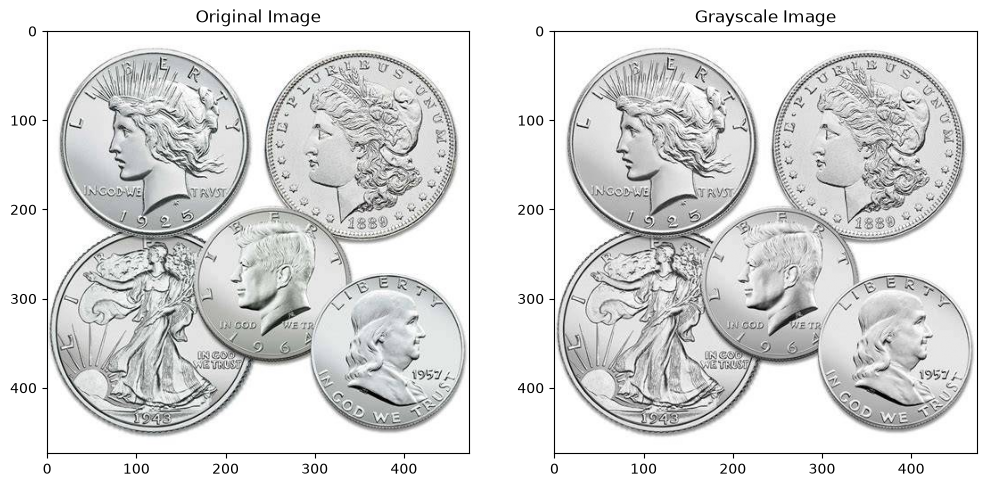

In [27]:
# Step 2: Convert image to grayscale
imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 12))
plt.subplot(121)
plt.imshow(image[:, :, ::-1])
plt.title("Original Image")

plt.subplot(122)
plt.imshow(imageGray, cmap="gray")
plt.title("Grayscale Image")
plt.show()


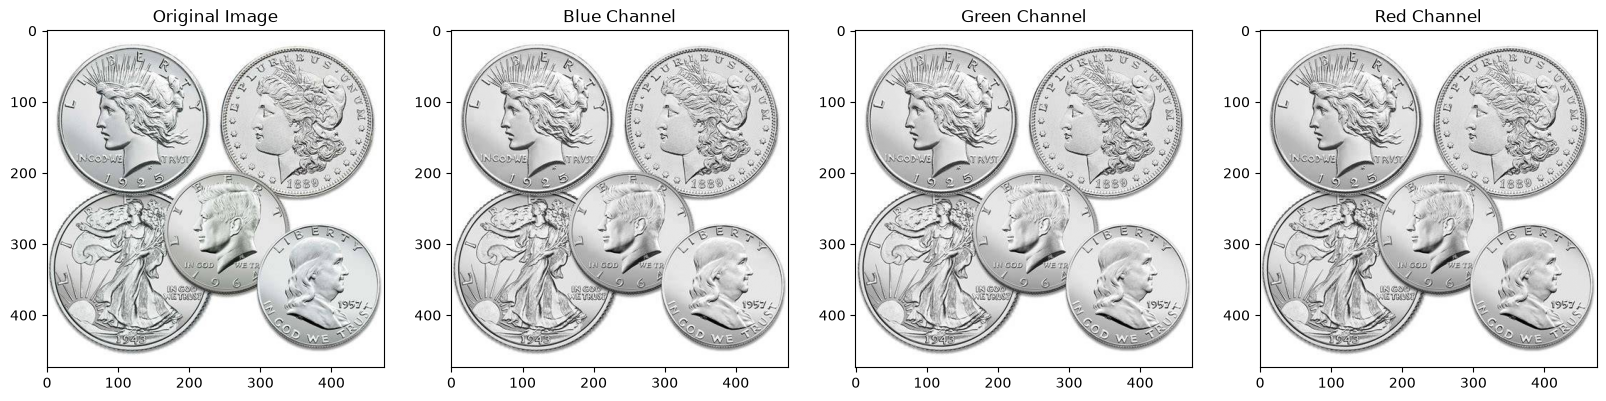

In [28]:
# Step 3: Split image into B, G and R channels
imageB, imageG, imageR = cv2.split(image)

plt.figure(figsize=(20, 12))
plt.subplot(141)
plt.imshow(image[:, :, ::-1])
plt.title("Original Image")

plt.subplot(142)
plt.imshow(imageB, cmap="gray")
plt.title("Blue Channel")

plt.subplot(143)
plt.imshow(imageG, cmap="gray")
plt.title("Green Channel")

plt.subplot(144)
plt.imshow(imageR, cmap="gray")
plt.title("Red Channel")

plt.show()


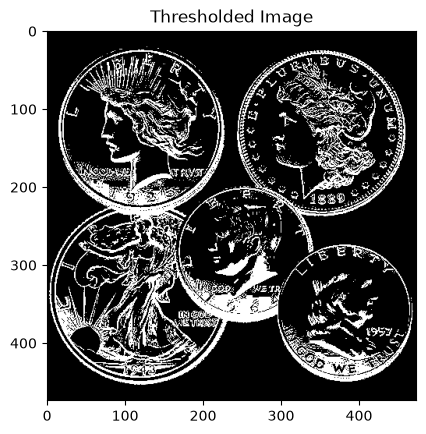

In [29]:
# Step 4: Thresholding
_, imageThreshold = cv2.threshold(
    imageG,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.imshow(imageThreshold, cmap="gray")
plt.title("Thresholded Image")
plt.show()

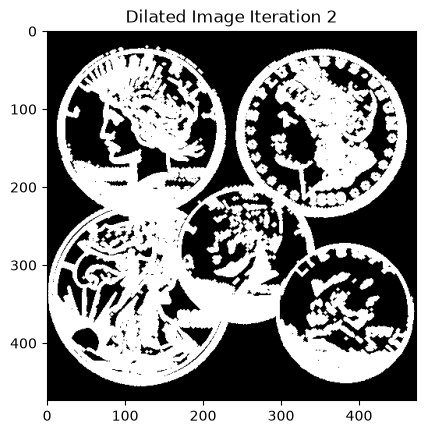

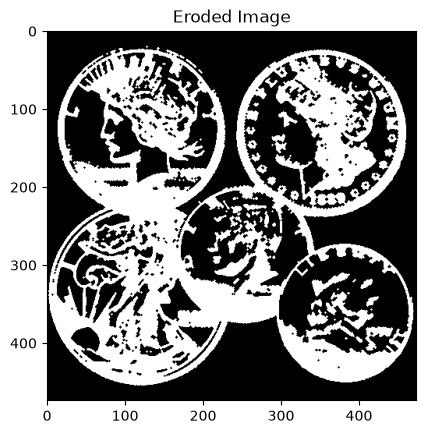

In [30]:
# Step 5: Morphological operations
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

imageDilated = cv2.dilate(
    imageThreshold,
    kernel,
    iterations=1
)

imageDilated2 = cv2.dilate(
    imageThreshold,
    kernel,
    iterations=2
)

plt.imshow(imageDilated2, cmap="gray")
plt.title("Dilated Image Iteration 2")
plt.show()


imageEroded = cv2.erode(
    imageDilated2,
    kernel,
    iterations=1
)

plt.imshow(imageEroded, cmap="gray")
plt.title("Eroded Image")
plt.show()


In [31]:
# Step 6: Create SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()

params.blobColor = 0
params.minDistBetweenBlobs = 2

# Filter by Area
params.filterByArea = False

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.8

# Filter by Inertia
params.filterByInertia = True
params.minInertiaRatio = 0.8

detector = cv2.SimpleBlobDetector_create(params)



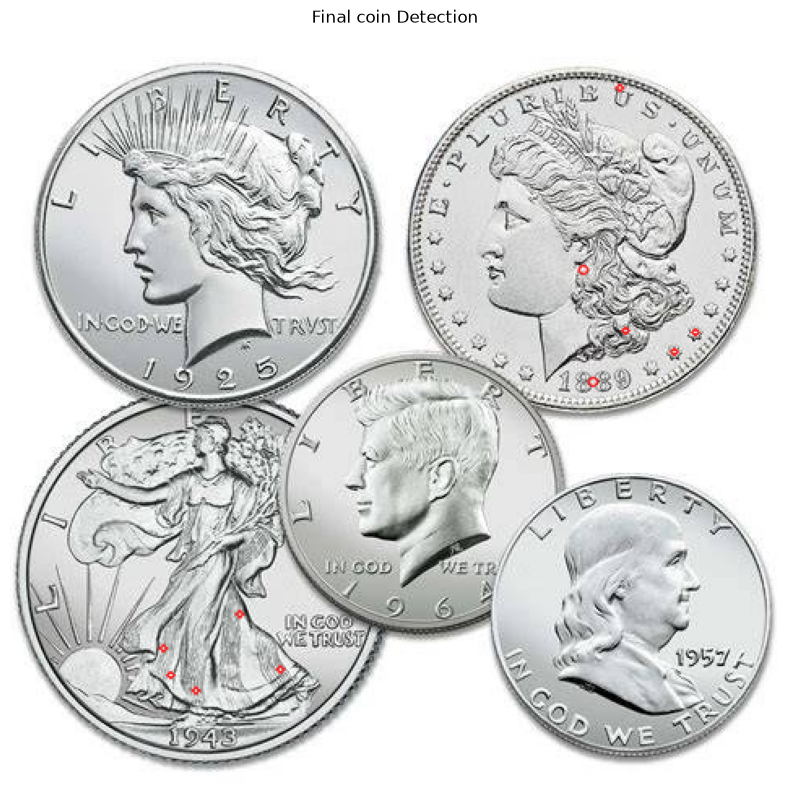

Number of shells: 5


In [34]:
# Step 7: Detect blobs
keypoints = detector.detect(imageEroded)

# Draw detected coins
output = cv2.drawKeypoints(
    image,
    keypoints,
    np.array([]),
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 10))
plt.imshow(output[:, :, ::-1])
plt.title("Final coin Detection")
plt.axis("off")
plt.show()


# Print number of detected coins
print(f"Number of shells: {len(keypoints)-6}")